# AG-HYPOPT · Trial 18

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Seventeen trials recorded, objective order: trial_09 0.1657 (BEST), trial_14 0.1679, trial_17 0.1816, trial_05 0.1863, trial_11 0.1883, trial_01 0.1907, trial_07 0.1940, trial_12 0.1941, trial_13 0.1941, trial_08 0.1948, trial_04 0.1987, trial_15 0.2046, trial_16 0.2058, trial_02 0.2075, trial_06 0.2203, trial_03 0.2472, trial_10 0.3727 (worst). Recap: mu_fit is pinned at ~half of mu_true for every config (objective floor); the objective is the gamma term, dominated by low transmission, and it varies widely run-to-run even for near-identical configs (trial_09 vs trial_17). The sweet-spot band (high sigma_ref ~22-25, low-to-mid lr_mu, high lr_gamma ~0.85-0.92, moderate anneal ~0.39-0.6) holds essentially all the top results. TPE (17/5) is exploiting. Only 3 trials remain before the cap. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_18'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (17/5 trials)
ID |     ei | params
 1 | 2.2757 | {"gamma_anneal": 0.3029980108189514, "lr_gamma": 0.863241887827469, "lr_mu": 20.783977474846747, "sigma_ref": 25.0}
 2 | 1.6149 | {"gamma_anneal": 0.75, "lr_gamma": 0.9049286517401314, "lr_mu": 17.0056129699903, "sigma_ref": 12.586763536168792}
 3 | 2.3032 | {"gamma_anneal": 0.332694846672727, "lr_gamma": 0.8598573398570646, "lr_mu": 20.65415277541107, "sigma_ref": 25.0}
 4 | 2.8942 | {"gamma_anneal": 0.5975325817857566, "lr_gamma": 0.8978568237433998, "lr_mu": 9.021264784890075, "sigma_ref": 25.0}
 5 | 0.9878 | {"gamma_anneal": 0.4951883339486573, "lr_gamma": 0.8846129756226739, "lr_mu": 23.71047984160061, "sigma_ref": 19.56527005480905}
 6 | 0.2896 | {"gamma_anneal": 0.012773009690492554, "lr_gamma": 0.5157960028814634, "lr_mu": 11.074184504322105, "sigma_ref": 20.126430848341368}
 7 | 0.9841 | {"gamma_anneal": 0.016876708810755287, "lr_gamma": 0.8015110385052273, "lr_mu": 5.0, "sigma_ref": 25.0}
 8 | 0.8889 | {"gamma_a

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

TPE (17/5) ranks by expected improvement. The highest-EI candidate is candidate 4 (EI 2.89): gamma_anneal 0.598, lr_gamma 0.898, lr_mu 9.02, sigma_ref 25.0 -- inside the sweet-spot band (high sigma_ref at the 25.0 boundary, high lr_gamma, moderate-to-strong anneal) with lr_mu 9.0 slightly above the best trials' 5.7-6.8 but well within the tested good range. The runner-ups (candidates 3 and 1: EI 2.30/2.28) push lr_mu to ~20.7, which has been mid-pack. So the top-EI pick is the cleanest continuation of the sweet spot. I choose candidate 4.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4               # highest-EI TPE pick, inside the sweet spot


chosen: {'gamma_anneal': 0.5975325817857566, 'lr_gamma': 0.8978568237433998, 'lr_mu': 9.021264784890075, 'sigma_ref': 25.0}
Running  1nW Trans05 ... 

μ 9.39 -> 4.71 | γ 8.5 -> 3.39 | NLL 1.29


Running  1nW Trans20 ... 

μ 17.32 -> 8.67 | γ 8.5 -> 4.03 | NLL 3.05


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 51.03 | γ 14.1 -> 13.60 | NLL 3.21


Running 3nW Trans100 ... 

μ 175.71 -> 86.75 | γ 14.1 -> 14.20 | NLL 2.79



Total: 2.4 min


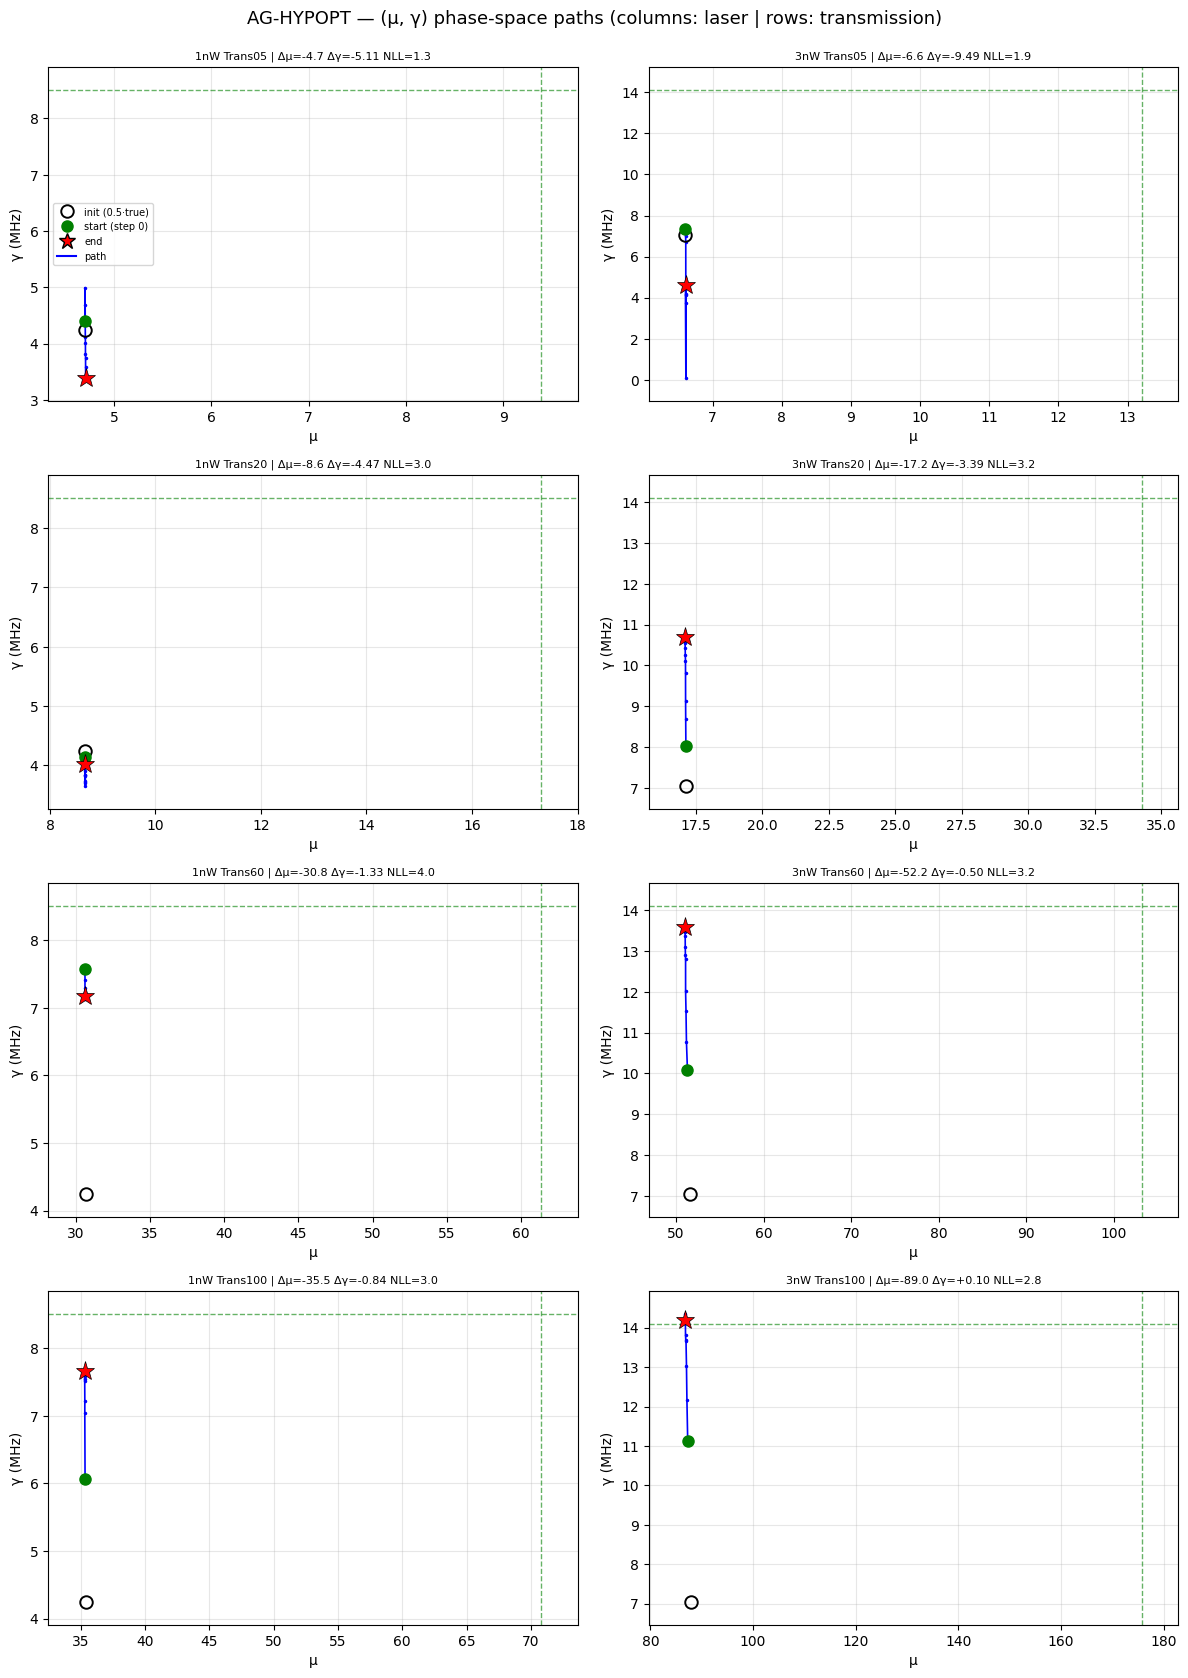

trial finished in 2.4 min
objective = 0.1999 ± 0.0344
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.71   -49.9 |     8.50    3.39   -60.1
1nW Trans20    17.32    8.67   -49.9 |     8.50    4.03   -52.6
1nW Trans60    61.37   30.60   -50.1 |     8.50    7.17   -15.6
1nW Trans100   70.82   35.33   -50.1 |     8.50    7.66    -9.8
3nW Trans05    13.20    6.61   -49.9 |    14.10    4.61   -67.3
3nW Trans20    34.28   17.09   -50.1 |    14.10   10.71   -24.0
3nW Trans60   103.20   51.03   -50.6 |    14.10   13.60    -3.6
3nW Trans100  175.71   86.75   -50.6 |    14.10   14.20    +0.7

μ: RMSE 40.741 (rel 50.2%, bias -30.565) | γ: RMSE 4.336 (rel 38.5%, bias -3.128)


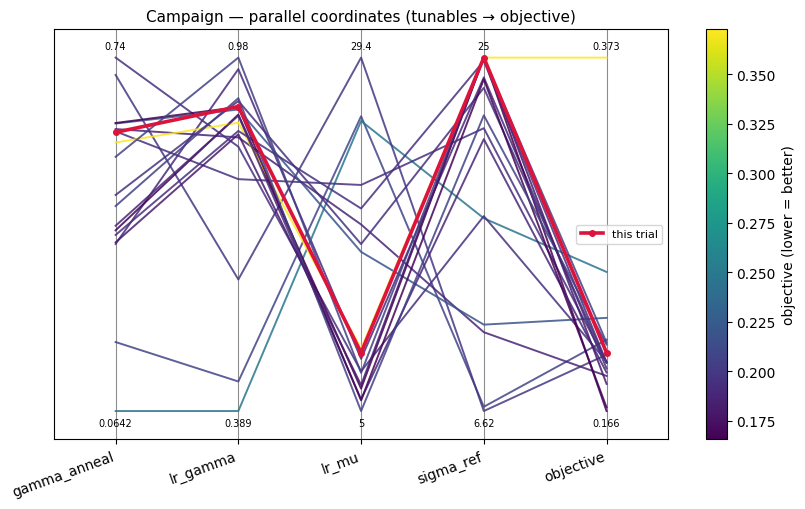

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 18, thirteenth TPE-driven trial; highest-EI pick, inside the sweet spot: sigma_ref 25.0, lr_mu 9.02, lr_gamma 0.898, gamma_anneal 0.598. Result: objective 0.1999 +/- 0.0344, mid-pack (similar to trial_04/15/16); runtime 2.4 min. mu_fit is unchanged at a uniform ~half-truth (Delta-mu% -49.9 to -50.6; mu RMSE 40.74, relative 50.2%). gamma_fit: high transmission good (3 nW Trans60/100: -3.6/+0.7%; 1 nW Trans100 -9.8%) but low transmission degraded (1 nW Trans05 -60.1%, 1 nW Trans20 -52.6%; 3 nW Trans05 -67.3%), gamma RMSE 4.34 (relative 38.5%). Again a sweet-spot-band config that did not rescue the Trans05 gamma.

**Summary:** Trial 18 (sigma_ref 25.0, lr_mu 9.02, lr_gamma 0.898, gamma_anneal 0.598) -> objective 0.1999 +/- 0.0344, mid-pack; high-T gamma good but Trans05/20 gamma still degraded.
**Key insight:** Mid/high-transmission gamma is reliably recovered whenever sigma_ref is high and lr_gamma is high, but the low-transmission gamma (which dominates the objective) remains the persistent, unstable failure across every config.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the real-data attractor note from trial_01 still stands.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 18 (sigma_ref 25.0, lr_mu 9.02, lr_gamma 0.898, gamma_anneal 0.598): objective 0.1999 +/- 0.0344, mid-pack; high-T gamma good but Trans05/20 gamma still degraded'
KEY_INSIGHT = 'Mid/high-transmission gamma is reliably recovered with high sigma_ref and high lr_gamma, but the low-transmission gamma -- which dominates the objective -- remains the persistent, unstable failure across every config.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_18 | current best: trial_09


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_19.ipynb. Open it and follow its cells from the top.
